In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from smt.surrogate_models import KRG
from smt.design_space import DesignSpace
from scipy.optimize import differential_evolution
from sklearn.metrics import mean_squared_error

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("="*80)
print("CHAPTER 5: SURROGATE-BASED OPTIMISATION")
print("="*80)
print("\nObjectives:")
print("  1. Single-objective optimisation of TR and PD")
print("  2. Multi-objective optimisation and Pareto front generation")
print("  3. Interpretation of design trade-offs")
print("="*80)

CHAPTER 5: SURROGATE-BASED OPTIMISATION

Objectives:
  1. Single-objective optimisation of TR and PD
  2. Multi-objective optimisation and Pareto front generation
  3. Interpretation of design trade-offs


In [4]:
data = np.loadtxt('/Users/dekoszero/Desktop/3rd year/Individual Engineering Project - MECH3890/coding/Raw Data/heat sink/heatsink.txt')

G1 = data[:, 0:1]
G2 = data[:, 1:2]
TR = data[:, 2:3]
PD = data[:, 3:4]

X = np.hstack((G1, G2))
y_TR = TR.ravel()
y_PD = PD.ravel()

xlimits = np.array([
    [X[:, 0].min(), X[:, 0].max()],
    [X[:, 1].min(), X[:, 1].max()]
])

print("Design space:")
print(f"  G1: [{xlimits[0,0]:.4f}, {xlimits[0,1]:.4f}]")
print(f"  G2: [{xlimits[1,0]:.4f}, {xlimits[1,1]:.4f}]")
print(f"  Number of samples: {len(X)}")
print(f"  TR range: [{y_TR.min():.4f}, {y_TR.max():.4f}]")
print(f"  PD range: [{y_PD.min():.4f}, {y_PD.max():.4f}]")

Design space:
  G1: [0.4000, 1.0000]
  G2: [0.4000, 1.0000]
  Number of samples: 30
  TR range: [0.1619, 0.2473]
  PD range: [12553.0800, 38679.5700]


In [5]:
design_space = DesignSpace(xlimits)

sm_TR = KRG(
    design_space=design_space,
    theta0=[1e-2],
    print_global=False,
    hyper_opt='Cobyla'
)
sm_TR.set_training_values(X, y_TR)
sm_TR.train()

sm_PD = KRG(
    design_space=design_space,
    theta0=[1e-2],
    print_global=False,
    hyper_opt='Cobyla'
)
sm_PD.set_training_values(X, y_PD)
sm_PD.train()

y_TR_pred = sm_TR.predict_values(X).ravel()
y_PD_pred = sm_PD.predict_values(X).ravel()

rmse_TR = np.sqrt(mean_squared_error(y_TR, y_TR_pred))
rmse_PD = np.sqrt(mean_squared_error(y_PD, y_PD_pred))

print("Surrogates trained successfully")
print(f"TR training RMSE: {rmse_TR:.6f}")
print(f"PD training RMSE: {rmse_PD:.6f}")

Surrogates trained successfully
TR training RMSE: 0.000000
PD training RMSE: 0.000004


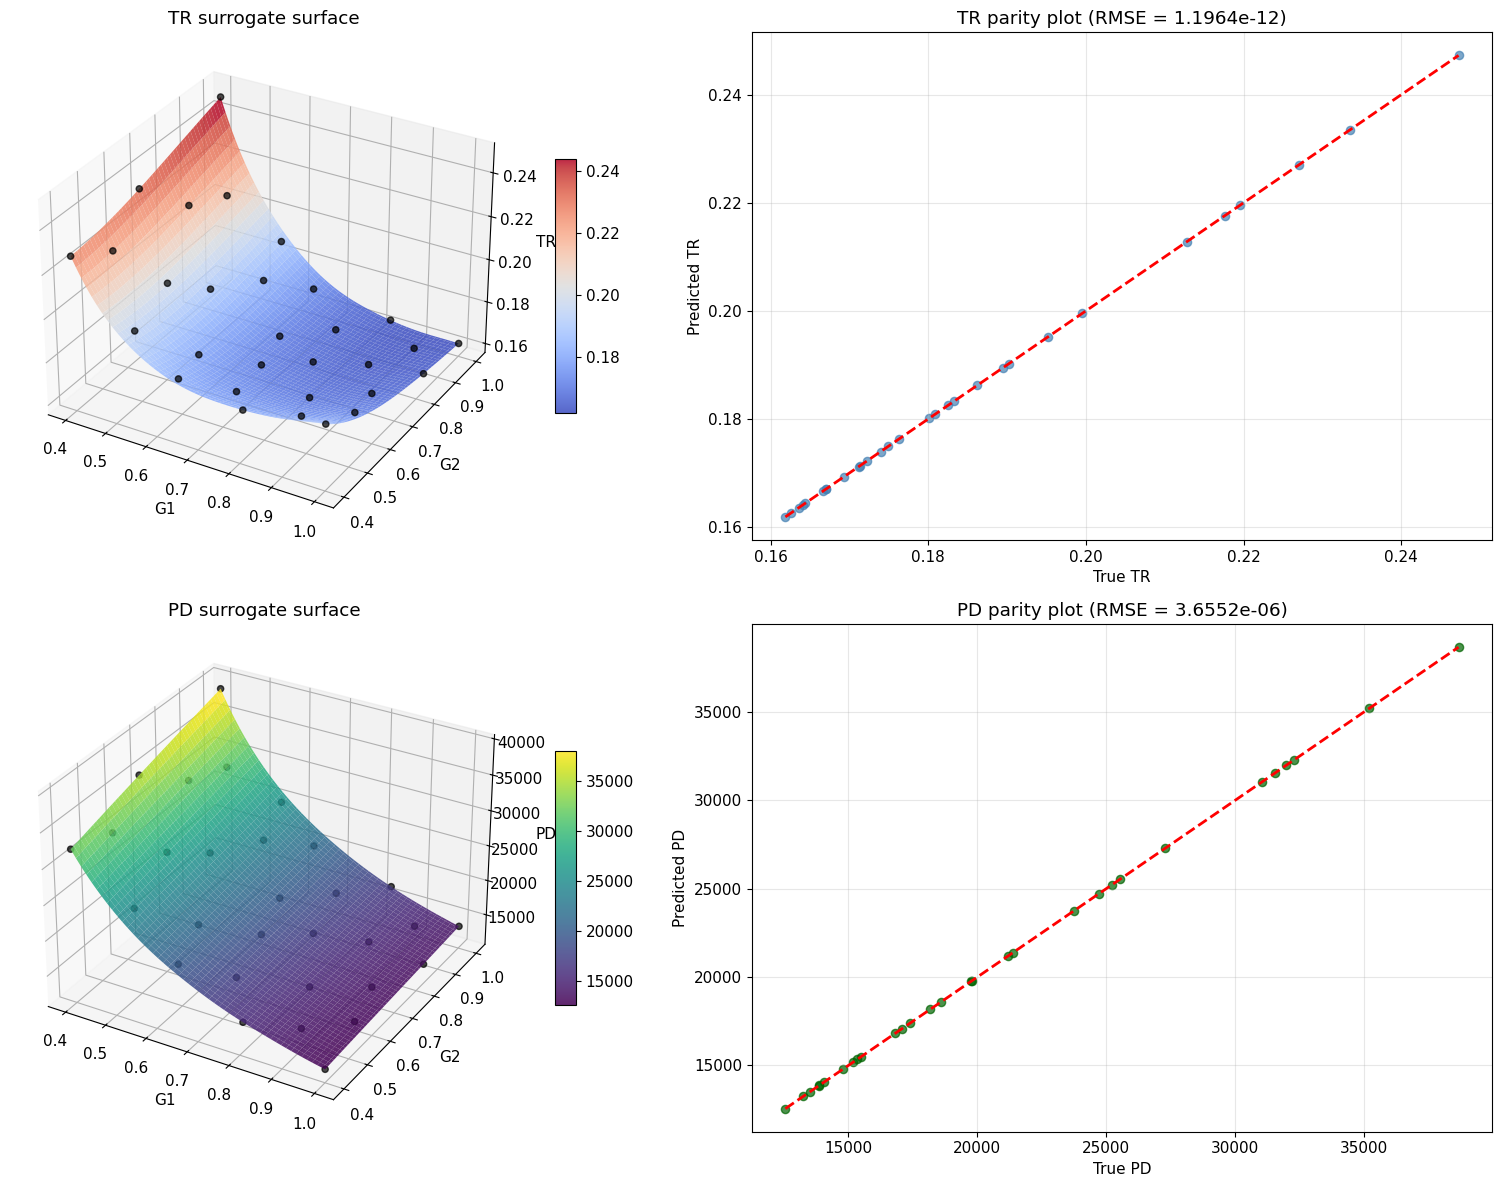

In [6]:
n_grid = 100
g1_plot = np.linspace(xlimits[0, 0], xlimits[0, 1], n_grid)
g2_plot = np.linspace(xlimits[1, 0], xlimits[1, 1], n_grid)
G1_grid, G2_grid = np.meshgrid(g1_plot, g2_plot)
X_grid = np.column_stack((G1_grid.ravel(), G2_grid.ravel()))

TR_grid = sm_TR.predict_values(X_grid).reshape(G1_grid.shape)
PD_grid = sm_PD.predict_values(X_grid).reshape(G1_grid.shape)

fig = plt.figure(figsize=(16, 12))

# TR 3D surface
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(
    G1_grid, G2_grid, TR_grid,
    cmap='coolwarm',
    edgecolor='none',
    alpha=0.85
)
ax1.scatter(X[:, 0], X[:, 1], y_TR, c='black', s=20, alpha=0.7)
ax1.set_title("TR surrogate surface")
ax1.set_xlabel("G1")
ax1.set_ylabel("G2")
ax1.set_zlabel("TR")
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=12)

# TR parity plot
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(y_TR, y_TR_pred, s=35, alpha=0.7, color='steelblue')
mn = min(y_TR.min(), y_TR_pred.min())
mx = max(y_TR.max(), y_TR_pred.max())
ax2.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
ax2.set_title(f"TR parity plot (RMSE = {rmse_TR:.4e})")
ax2.set_xlabel("True TR")
ax2.set_ylabel("Predicted TR")
ax2.grid(True, alpha=0.3)

# PD 3D surface
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf2 = ax3.plot_surface(
    G1_grid, G2_grid, PD_grid,
    cmap='viridis',
    edgecolor='none',
    alpha=0.85
)
ax3.scatter(X[:, 0], X[:, 1], y_PD, c='black', s=20, alpha=0.7)
ax3.set_title("PD surrogate surface")
ax3.set_xlabel("G1")
ax3.set_ylabel("G2")
ax3.set_zlabel("PD")
fig.colorbar(surf2, ax=ax3, shrink=0.5, aspect=12)

# PD parity plot
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(y_PD, y_PD_pred, s=35, alpha=0.7, color='darkgreen')
mn = min(y_PD.min(), y_PD_pred.min())
mx = max(y_PD.max(), y_PD_pred.max())
ax4.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
ax4.set_title(f"PD parity plot (RMSE = {rmse_PD:.4e})")
ax4.set_xlabel("True PD")
ax4.set_ylabel("Predicted PD")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
def objective_TR(x):
    x = np.atleast_2d(x)
    return sm_TR.predict_values(x)[0, 0]

result_TR = differential_evolution(
    objective_TR,
    bounds=xlimits,
    seed=42,
    maxiter=300,
    popsize=20,
    tol=1e-6
)

x_opt_TR = result_TR.x
TR_opt = result_TR.fun
PD_at_TR_opt = sm_PD.predict_values(x_opt_TR.reshape(1, -1))[0, 0]

print("="*80)
print("Single-objective optimisation: minimise TR")
print("="*80)
print(f"Optimal G1 = {x_opt_TR[0]:.4f}")
print(f"Optimal G2 = {x_opt_TR[1]:.4f}")
print(f"TR optimum = {TR_opt:.6f}")
print(f"PD at TR optimum = {PD_at_TR_opt:.6f}")

Single-objective optimisation: minimise TR
Optimal G1 = 1.0000
Optimal G2 = 1.0000
TR optimum = 0.161879
PD at TR optimum = 13867.914280


In [8]:
def objective_PD(x):
    x = np.atleast_2d(x)
    return sm_PD.predict_values(x)[0, 0]

result_PD = differential_evolution(
    objective_PD,
    bounds=xlimits,
    seed=42,
    maxiter=300,
    popsize=20,
    tol=1e-6
)

x_opt_PD = result_PD.x
PD_opt = result_PD.fun
TR_at_PD_opt = sm_TR.predict_values(x_opt_PD.reshape(1, -1))[0, 0]

print("="*80)
print("Single-objective optimisation: minimise PD")
print("="*80)
print(f"Optimal G1 = {x_opt_PD[0]:.4f}")
print(f"Optimal G2 = {x_opt_PD[1]:.4f}")
print(f"PD optimum = {PD_opt:.6f}")
print(f"TR at PD optimum = {TR_at_PD_opt:.6f}")

Single-objective optimisation: minimise PD
Optimal G1 = 1.0000
Optimal G2 = 0.4000
PD optimum = 12553.080418
TR at PD optimum = 0.186238


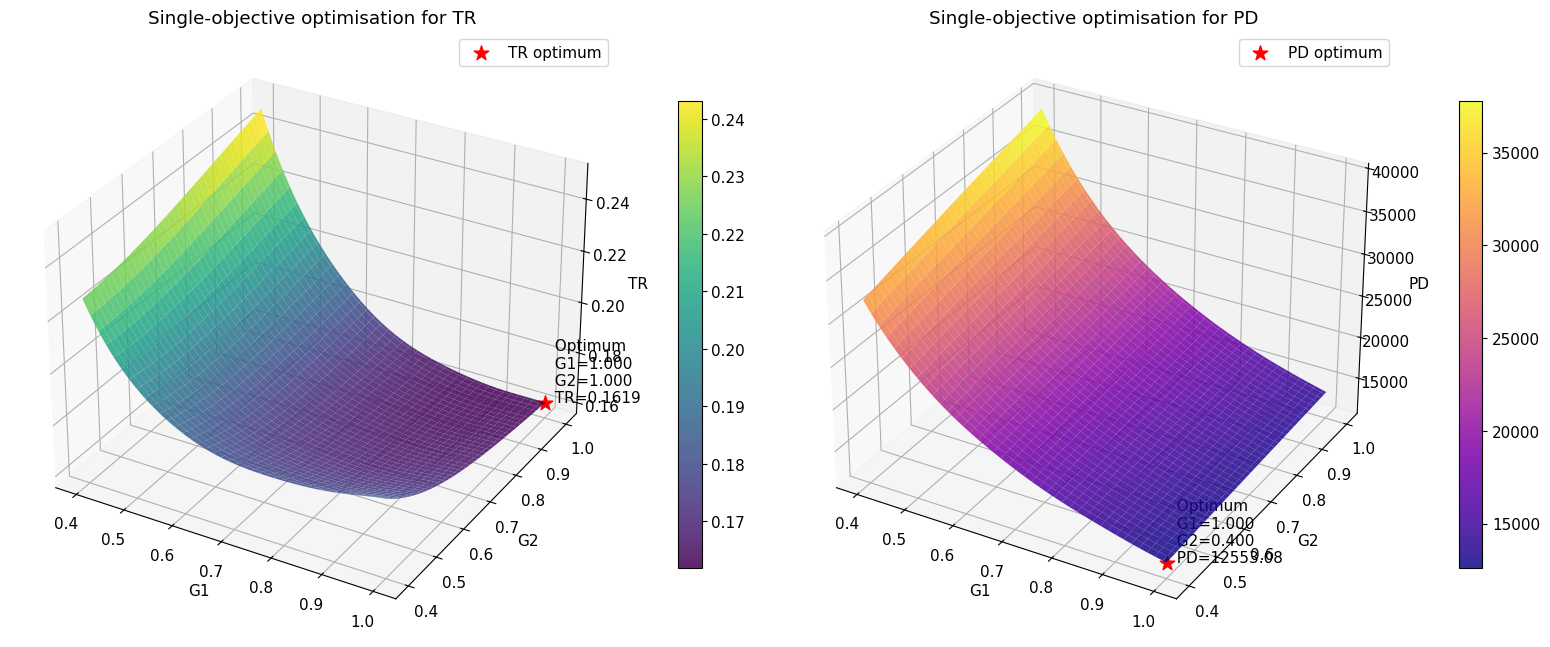

Single-objective optimum for TR:
 G1 = 0.999999, G2 = 1.000000, TR = 0.161879

Single-objective optimum for PD:
 G1 = 1.000000, G2 = 0.400000, PD = 12553.080418


In [ ]:
# CELL 7 — 3D plots of the single-objective optimisation points for TR and PD

from mpl_toolkits.mplot3d import Axes3D

# --- helper for safe prediction on a grid ---
def predict_on_grid(sm, X1, X2):
    Xg = np.column_stack([X1.ravel(), X2.ravel()])
    Z = sm.predict_values(Xg).reshape(X1.shape)
    return Z

# --- design grid ---
n_grid = 80
g1 = np.linspace(xlimits[0, 0], xlimits[0, 1], n_grid)
g2 = np.linspace(xlimits[1, 0], xlimits[1, 1], n_grid)
G1_grid, G2_grid = np.meshgrid(g1, g2)

Z_TR = predict_on_grid(sm_TR, G1_grid, G2_grid)
Z_PD = predict_on_grid(sm_PD, G1_grid, G2_grid)

# ------------------------------------------------------------------
# If your optimisation cells already created these variables, keep them.
# Otherwise these fallback blocks will compute them.
# ------------------------------------------------------------------

if 'x_opt_TR' not in globals():
    def obj_TR(x):
        return float(sm_TR.predict_values(np.array(x).reshape(1, -1))[0, 0])

    res_TR = differential_evolution(
        obj_TR,
        bounds=[tuple(xlimits[0]), tuple(xlimits[1])],
        seed=42
    )
    x_opt_TR = res_TR.x
    y_opt_TR = res_TR.fun
else:
    y_opt_TR = float(sm_TR.predict_values(np.array(x_opt_TR).reshape(1, -1))[0, 0])

if 'x_opt_PD' not in globals():
    def obj_PD(x):
        return float(sm_PD.predict_values(np.array(x).reshape(1, -1))[0, 0])

    res_PD = differential_evolution(
        obj_PD,
        bounds=[tuple(xlimits[0]), tuple(xlimits[1])],
        seed=42
    )
    x_opt_PD = res_PD.x
    y_opt_PD = res_PD.fun
else:
    y_opt_PD = float(sm_PD.predict_values(np.array(x_opt_PD).reshape(1, -1))[0, 0])

# --- figure ---
fig = plt.figure(figsize=(16, 7))

# ===== TR surface =====
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(G1_grid, G2_grid, Z_TR, cmap='viridis', alpha=0.85, edgecolor='none')
ax1.scatter(
    x_opt_TR[0], x_opt_TR[1], y_opt_TR,
    color='red', s=120, marker='*', label='TR optimum'
)
ax1.set_title('Single-objective optimisation for TR')
ax1.set_xlabel('G1')
ax1.set_ylabel('G2')
ax1.set_zlabel('TR')
ax1.legend()
fig.colorbar(surf1, ax=ax1, shrink=0.7, pad=0.08)

# annotate optimum
ax1.text(
    x_opt_TR[0], x_opt_TR[1], y_opt_TR,
    f'  Optimum\n  G1={x_opt_TR[0]:.3f}\n  G2={x_opt_TR[1]:.3f}\n  TR={y_opt_TR:.4f}',
    color='black'
)

# ===== PD surface =====
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(G1_grid, G2_grid, Z_PD, cmap='plasma', alpha=0.85, edgecolor='none')
ax2.scatter(
    x_opt_PD[0], x_opt_PD[1], y_opt_PD,
    color='red', s=120, marker='*', label='PD optimum'
)
ax2.set_title('Single-objective optimisation for PD')
ax2.set_xlabel('G1')
ax2.set_ylabel('G2')
ax2.set_zlabel('PD')
ax2.legend()
fig.colorbar(surf2, ax=ax2, shrink=0.7, pad=0.08)

# annotate optimum
ax2.text(
    x_opt_PD[0], x_opt_PD[1], y_opt_PD,
    f'  Optimum\n  G1={x_opt_PD[0]:.3f}\n  G2={x_opt_PD[1]:.3f}\n  PD={y_opt_PD:.2f}',
    color='black'
)

plt.tight_layout()
plt.show()

print("Single-objective optimum for TR:")
print(f" G1 = {x_opt_TR[0]:.6f}, G2 = {x_opt_TR[1]:.6f}, TR = {y_opt_TR:.6f}")

print("\nSingle-objective optimum for PD:")
print(f" G1 = {x_opt_PD[0]:.6f}, G2 = {x_opt_PD[1]:.6f}, PD = {y_opt_PD:.6f}")

In [10]:
def evaluate_objectives(x):
    x = np.atleast_2d(x)
    tr_val = sm_TR.predict_values(x)[0, 0]
    pd_val = sm_PD.predict_values(x)[0, 0]
    return tr_val, pd_val

weights = np.linspace(0, 1, 50)
solutions = []

for i, w in enumerate(weights):
    def weighted_objective(x):
        x = np.atleast_2d(x)
        tr_val = sm_TR.predict_values(x)[0, 0]
        pd_val = sm_PD.predict_values(x)[0, 0]

        tr_norm = (tr_val - y_TR.min()) / (y_TR.max() - y_TR.min())
        pd_norm = (pd_val - y_PD.min()) / (y_PD.max() - y_PD.min())

        return w * tr_norm + (1 - w) * pd_norm

    result = differential_evolution(
        weighted_objective,
        bounds=xlimits,
        seed=42 + i,
        maxiter=200,
        popsize=15,
        tol=1e-6
    )

    x_sol = result.x
    tr_val, pd_val = evaluate_objectives(x_sol)

    solutions.append({
        "weight": w,
        "G1": x_sol[0],
        "G2": x_sol[1],
        "TR": tr_val,
        "PD": pd_val
    })

pareto_df = pd.DataFrame(solutions)
print(f"Generated {len(pareto_df)} candidate multi-objective solutions")

Generated 50 candidate multi-objective solutions


In [11]:
def is_dominated(row, df):
    for _, other in df.iterrows():
        if ((other["TR"] <= row["TR"]) and (other["PD"] <= row["PD"]) and
            ((other["TR"] < row["TR"]) or (other["PD"] < row["PD"]))):
            return True
    return False

pareto_mask = [not is_dominated(row, pareto_df) for _, row in pareto_df.iterrows()]
pareto_optimal_df = pareto_df.loc[pareto_mask].copy()
pareto_optimal_df = pareto_optimal_df.sort_values("TR").reset_index(drop=True)

print(f"Non-dominated solutions: {len(pareto_optimal_df)}")
print(pareto_optimal_df.head())

Non-dominated solutions: 32
     weight   G1   G2        TR            PD
0  1.000000  1.0  1.0  0.161879  13867.900000
1  0.816327  1.0  1.0  0.161879  13867.899997
2  0.755102  1.0  1.0  0.161879  13867.899991
3  0.591837  1.0  1.0  0.161879  13867.899981
4  0.632653  1.0  1.0  0.161879  13867.899975


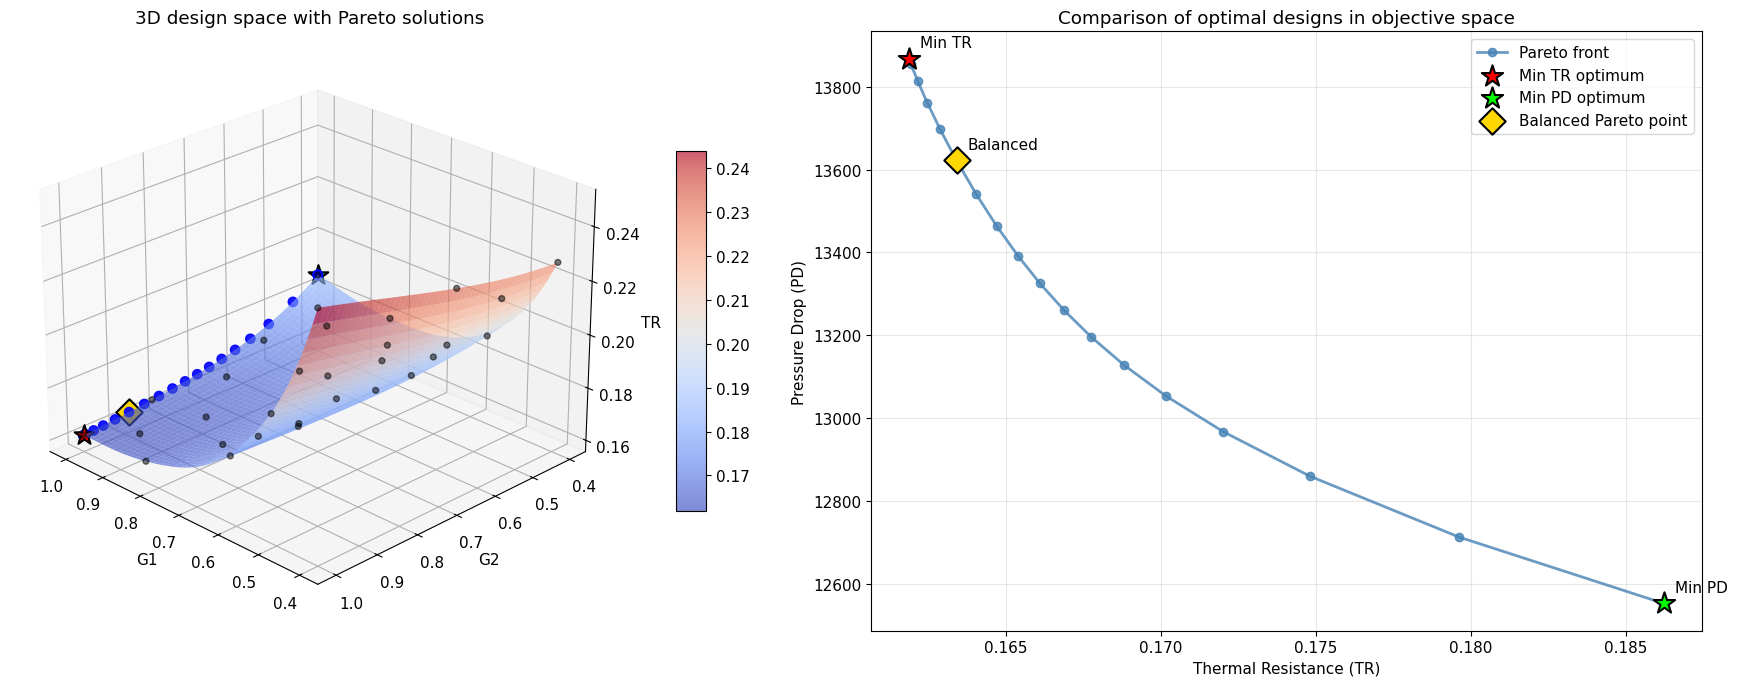

COMPARISON OF OPTIMAL DESIGNS
         Design       G1       G2       TR           PD
         Min TR 0.999999 1.000000 0.161879 13867.914280
         Min PD 1.000000 0.400000 0.186238 12553.080418
Balanced Pareto 1.000000 0.889125 0.163420 13622.153108


In [13]:
# Cell 10: 3D design-space visualisation and comparison of optimal designs
from mpl_toolkits.mplot3d import Axes3D

# Choose one representative balanced Pareto point
mid_idx = len(pareto_optimal_df) // 2
balanced_point = pareto_optimal_df.iloc[mid_idx]

fig = plt.figure(figsize=(18, 7))

# ------------------------------------------------------------------
# Plot 1: 3D design space using TR surface with Pareto solutions
# ------------------------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

surf1 = ax1.plot_surface(
    G1_grid, G2_grid, TR_grid,
    cmap='coolwarm',
    edgecolor='none',
    alpha=0.65
)

# Original CFD points
ax1.scatter(
    X[:, 0], X[:, 1], y_TR,
    c='black', s=18, alpha=0.5, label='CFD data'
)

# Pareto solutions shown on TR surface
ax1.scatter(
    pareto_optimal_df["G1"],
    pareto_optimal_df["G2"],
    pareto_optimal_df["TR"],
    c='blue', s=45, alpha=0.9, label='Pareto solutions'
)

# Single-objective TR optimum
ax1.scatter(
    x_opt_TR[0], x_opt_TR[1], TR_opt,
    c='red', s=220, marker='*',
    edgecolors='black', linewidths=1.5, label='Min TR optimum'
)

# Single-objective PD optimum shown with its TR value
ax1.scatter(
    x_opt_PD[0], x_opt_PD[1], TR_at_PD_opt,
    c='lime', s=220, marker='*',
    edgecolors='black', linewidths=1.5, label='Min PD optimum'
)

# Balanced Pareto point
ax1.scatter(
    balanced_point["G1"], balanced_point["G2"], balanced_point["TR"],
    c='gold', s=180, marker='D',
    edgecolors='black', linewidths=1.5, label='Balanced Pareto point'
)

ax1.set_title("3D design space with Pareto solutions")
ax1.set_xlabel("G1")
ax1.set_ylabel("G2")
ax1.set_zlabel("TR")
ax1.view_init(elev=25, azim=135)
fig.colorbar(surf1, ax=ax1, shrink=0.6, aspect=12, pad=0.08)

# ------------------------------------------------------------------
# Plot 2: Comparison of single-objective optima in objective space
# ------------------------------------------------------------------
ax2 = fig.add_subplot(1, 2, 2)

# All non-dominated solutions
ax2.plot(
    pareto_optimal_df["TR"],
    pareto_optimal_df["PD"],
    'o-', color='steelblue', alpha=0.8, linewidth=2,
    label='Pareto front'
)

# Min TR optimum
ax2.scatter(
    TR_opt, PD_at_TR_opt,
    c='red', s=260, marker='*',
    edgecolors='black', linewidths=1.5, label='Min TR optimum', zorder=10
)

# Min PD optimum
ax2.scatter(
    TR_at_PD_opt, PD_opt,
    c='lime', s=260, marker='*',
    edgecolors='black', linewidths=1.5, label='Min PD optimum', zorder=10
)

# Balanced Pareto point
ax2.scatter(
    balanced_point["TR"], balanced_point["PD"],
    c='gold', s=180, marker='D',
    edgecolors='black', linewidths=1.5, label='Balanced Pareto point', zorder=10
)

# Annotate points
ax2.annotate(
    "Min TR",
    (TR_opt, PD_at_TR_opt),
    xytext=(8, 8),
    textcoords='offset points'
)
ax2.annotate(
    "Min PD",
    (TR_at_PD_opt, PD_opt),
    xytext=(8, 8),
    textcoords='offset points'
)
ax2.annotate(
    "Balanced",
    (balanced_point["TR"], balanced_point["PD"]),
    xytext=(8, 8),
    textcoords='offset points'
)

ax2.set_title("Comparison of optimal designs in objective space")
ax2.set_xlabel("Thermal Resistance (TR)")
ax2.set_ylabel("Pressure Drop (PD)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Print comparison table
# ------------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Design": ["Min TR", "Min PD", "Balanced Pareto"],
    "G1": [x_opt_TR[0], x_opt_PD[0], balanced_point["G1"]],
    "G2": [x_opt_TR[1], x_opt_PD[1], balanced_point["G2"]],
    "TR": [TR_opt, TR_at_PD_opt, balanced_point["TR"]],
    "PD": [PD_at_TR_opt, PD_opt, balanced_point["PD"]]
})

print("="*90)
print("COMPARISON OF OPTIMAL DESIGNS")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)